In [4]:
import sympy as sp
import networkx as nx
import numpy as np
import json

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tqdm

import linearframework.gen_graphs as gen
from linearframework.linear_framework_graph import LinearFrameworkGraph, hill_augmented_graph

this notebook contains numerical tests for the splitting probability and conditional first passage time on terminal core butterfly graphs

In [45]:
def det_matrix_minor(arr, i, j):
    minor = np.delete(np.delete(arr,i,axis=0), j, axis=1)
    return np.linalg.det(minor)

In [46]:
def calc_quantities(terminal_butterfly_edge_to_weight, k):

    terminal_butterfly = LinearFrameworkGraph(terminal_butterfly_edge_to_weight)
    hill_butterfly_1 = hill_augmented_graph(terminal_butterfly, '1')

    index_pk = hill_butterfly_1.nodes.index(f'p_{k}')
    correct_sp = det_matrix_minor(hill_butterfly_1.Lap, index_pk, index_pk)

    index_pbk = hill_butterfly_1.nodes.index(f'p_bar_{k}')
    incorrect_sp = det_matrix_minor(hill_butterfly_1.Lap, index_pbk, index_pbk)

    epsilon_sp =  incorrect_sp / correct_sp

    correct_to = 0
    incorrect_to = 0

    for j in hill_butterfly_1.nodes:
        index_j = hill_butterfly_1.nodes.index(f'p_bar_{k}')
        hill_butterfly_j = hill_augmented_graph(terminal_butterfly, j)

        jndex_pk = hill_butterfly_j.nodes.index(f'p_{k}')
        correct_to += det_matrix_minor(hill_butterfly_1.Lap, index_j, index_j) * det_matrix_minor(hill_butterfly_j.Lap, jndex_pk, jndex_pk)

        jndex_pbk = hill_butterfly_j.nodes.index(f'p_bar_{k}')
        incorrect_to += det_matrix_minor(hill_butterfly_1.Lap, index_j, index_j) * det_matrix_minor(hill_butterfly_j.Lap, jndex_pbk, jndex_pbk)
    
    trade_off = incorrect_to / correct_to

    epsilon_cmfpt = (1 / epsilon_sp) * trade_off
    
    return epsilon_sp, epsilon_cmfpt, trade_off

alpha = 5
k = 3

butterfly_t_eq_etw = gen.gen_core_butterfly_dict(alpha, k, tails = True)
calc_quantities(butterfly_t_eq_etw, k)

(0.20012410337472392, 1.0000118403500107, 0.20012647291415342)

In [47]:
def proofreading_monte_carlo(k, alphas, equilibrium, num_samples):

    epsilon_sp_by_alpha = {}
    epsilon_cmfpt_by_alpha = {}
    trade_off_by_alpha = {}

    for alpha in tqdm.tqdm(alphas):
        epsilon_sp_by_alpha[alpha] = []
        epsilon_cmfpt_by_alpha[alpha] = []
        trade_off_by_alpha[alpha] = []

        for i in range(num_samples):
            butterfly_t_eq_etw = gen.gen_core_butterfly_dict(alpha, k, equilibrium=equilibrium, tails = True)
            epsilon_sp, epsilon_cmfpt, trade_off =  calc_quantities(butterfly_t_eq_etw, k)

            epsilon_sp_by_alpha[alpha].append(epsilon_sp)
            epsilon_cmfpt_by_alpha[alpha].append(epsilon_cmfpt)
            trade_off_by_alpha[alpha].append(trade_off)
    
    return epsilon_sp_by_alpha, epsilon_cmfpt_by_alpha, trade_off_by_alpha

k = 2
num_samples = 3000
num_alphas = 100
max_alpha = 10

alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)
equilibrium = True

epsilon_sp_by_alpha, epsilon_cmfpt_by_alpha, trade_off_by_alpha = proofreading_monte_carlo(k, alphas, equilibrium, num_samples)

100%|██████████| 100/100 [01:10<00:00,  1.42it/s]


In [48]:
index = 3

quantity = epsilon_cmfpt_by_alpha
print(f'min: {min(quantity[alphas[index]])}')
print(f'max: {max(quantity[alphas[index]])}')
print(f'({(1 / alphas[index])}, {alphas[index]})')

min: 0.9774507561096518
max: 1.0992248709910368
(0.7874015748031494, 1.2700000000000002)


In [49]:
ks = [5, 7, 9]

num_samples = 100000
num_alphas = 150
max_alpha = 10
alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)

eq_datapoints = {}
neq_datapoints = {}

for k in ks:
    print(f'generating epsilon_sp, epsilon_cmfpt, trade_off samples for k={k} terminal butterfly graph . . .')
    
    print('equilibrium')
    eq_epsilon_sp_by_alpha, eq_epsilon_cmfpt_by_alpha, eq_trade_off_by_alpha = proofreading_monte_carlo(k, alphas, True, num_samples)

    eq_datapoints[k] = (eq_epsilon_sp_by_alpha, eq_epsilon_cmfpt_by_alpha, eq_trade_off_by_alpha)

    print('nonequilibrium')
    neq_epsilon_sp_by_alpha, neq_epsilon_cmfpt_by_alpha, neq_trade_off_by_alpha = proofreading_monte_carlo(k, alphas, False, num_samples)

    neq_datapoints[k] = (neq_epsilon_sp_by_alpha, neq_epsilon_cmfpt_by_alpha, neq_trade_off_by_alpha)
    

generating epsilon_sp, epsilon_cmfpt, trade_off samples for k=5 terminal butterfly graph . . .
equilibrium


100%|██████████| 150/150 [3:06:58<00:00, 74.79s/it]  


nonequilibrium


100%|██████████| 150/150 [14:27:47<00:00, 347.12s/it]   


generating epsilon_sp, epsilon_cmfpt, trade_off samples for k=7 terminal butterfly graph . . .
equilibrium


 37%|███▋      | 56/150 [9:56:20<16:41:00, 638.94s/it]  


KeyboardInterrupt: 

In [57]:
k = 5
out_file = open(f"splitting-probability-error-ratio/epsion_cmfpt-k{k}-datapoints.json", "w")  
    
json.dump((neq_datapoints[k], eq_datapoints[k]), out_file, indent = 6)  
    
out_file.close()  

In [10]:
filename = "splitting-probability-error-ratio/epsion_cmfpt-datapoints.json"
with open(filename) as file:
    data = json.load(file)


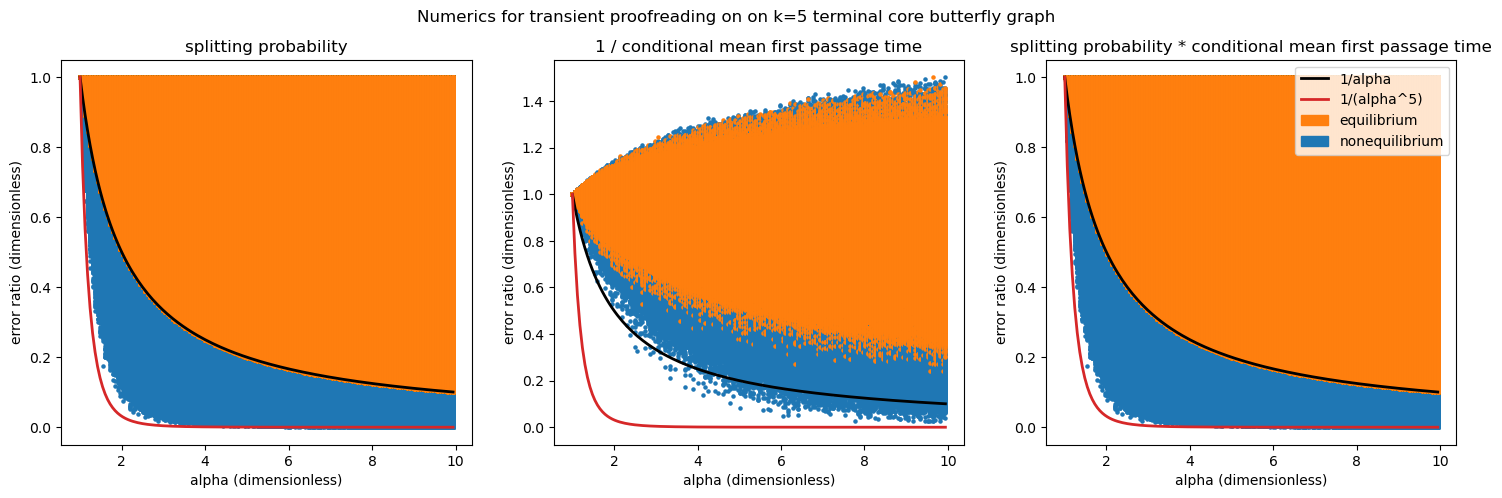

In [ ]:
def plot_transient_results(eq_datapoints, neq_datapoints, alphas,  k):
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Numerics for transient proofreading on on k={k} terminal core butterfly graph')

    for alpha in alphas:
        # plotting epsilon_sp datapoints
        ax0.scatter(alpha * np.ones(num_samples), neq_datapoints[k][0][alpha], color='tab:blue', s=5)
        ax0.scatter(alpha * np.ones(num_samples), eq_datapoints[k][0][alpha], color='tab:orange', s=5)

        # plotting epsilon_cmfpt datapoints
        ax1.scatter(alpha * np.ones(num_samples), 1/ np.array(neq_datapoints[k][1][alpha]), color='tab:blue', s=5)
        ax1.scatter(alpha * np.ones(num_samples), 1 / np.array(eq_datapoints[k][1][alpha]), color='tab:orange', s=5)

        #plotting trade_off datapoints
        ax2.scatter(alpha * np.ones(num_samples), neq_datapoints[k][2][alpha], color='tab:blue', s=5)
        ax2.scatter(alpha * np.ones(num_samples), eq_datapoints[k][2][alpha], color='tab:orange', s=5)

    k = int(k)
    # plotting epsilon_sp bounds
    ax0.plot(alphas, 1/alphas, color='black', label='1/alpha', linewidth=2)
    ax0.plot(alphas, 1/(alphas ** k), color='tab:red', label=f'1/(alpha^{k})', linewidth=2)
    ax0.set_xlabel('alpha (dimensionless)')
    ax0.set_ylabel("error ratio (dimensionless)")
    ax0.set_title("splitting probability")

    # plotting epsilon_cmfpt bounds
    ax1.plot(alphas, 1/(alphas), color='black', label='alpha', linewidth=2)
    ax1.plot(alphas, 1/(alphas ** k), color='tab:red', label=f'alpha^{k}', linewidth=2)

    ax1.set_xlabel('alpha (dimensionless)')
    ax1.set_ylabel("error ratio (dimensionless)")


    ax1.set_title(f'1 / conditional mean first passage time')
    # ax1.legend(loc='upper right', handles=handles)

    # plotting trade_off bounds and labels
    ax2.plot(alphas, 1/alphas, color='black', label='1/alpha', linewidth=2)
    ax2.plot(alphas, 1/(alphas ** k), color='tab:red', label=f'1/(alpha^{k})', linewidth=2)
    ax2.set_xlabel('alpha (dimensionless)')
    ax2.set_ylabel("error ratio (dimensionless)")


    equilibrium_patch = mpatches.Patch(color='tab:orange', label='equilibrium')
    non_equilibrium_patch = mpatches.Patch(color='tab:blue', label='nonequilibrium')
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([equilibrium_patch, non_equilibrium_patch])
    ax2.set_title(f'splitting probability * conditional mean first passage time')
    ax2.legend(loc='upper right', handles=handles)



num_samples = 100000
num_alphas = 150
max_alpha = 10
alphas = np.arange(1, max_alpha, (max_alpha - 1)/num_alphas)

k=5
plot_transient_results(eq_datapoints, neq_datapoints, alphas,  k)

In [ ]:

out_file = open(f"epsion_cmfpt-k{k}-datapoints-{datetime.datetime.now()}.json", "w")  

json.dump((neq_datapoints[k], eq_datapoints[k]), out_file, indent = 6)  
    
out_file.close()  

'test 2025-03-14 17:13:47.442543'